
-- status --
status
success    4415
fail       4185
failed     1181
succeed     219
Name: count, dtype: int64

-- card_type --
card_type
visa           2744
mastercard     2040
discover       1647
amex           1263
mastcard       1000
vsa             801
master card     194
Name: count, dtype: int64

-- city --
city
tehran     2658
tabriz     1368
isfahan    1073
karaj      1037
mashhad     900
shiraz      727
qom         669
ahvaz       632
thr         409
tehrn       332
thran        79
Name: count, dtype: int64

-- status --
status
fail       5366
success    4634
Name: count, dtype: int64

-- card_type --
card_type
visa          3545
mastercard    3234
discover      1647
amex          1263
Name: count, dtype: int64

-- city --
city
tehran     3478
tabriz     1368
isfahan    1073
karaj      1037
mashhad     900
shiraz      727
qom         669
ahvaz       632
Name: count, dtype: int64


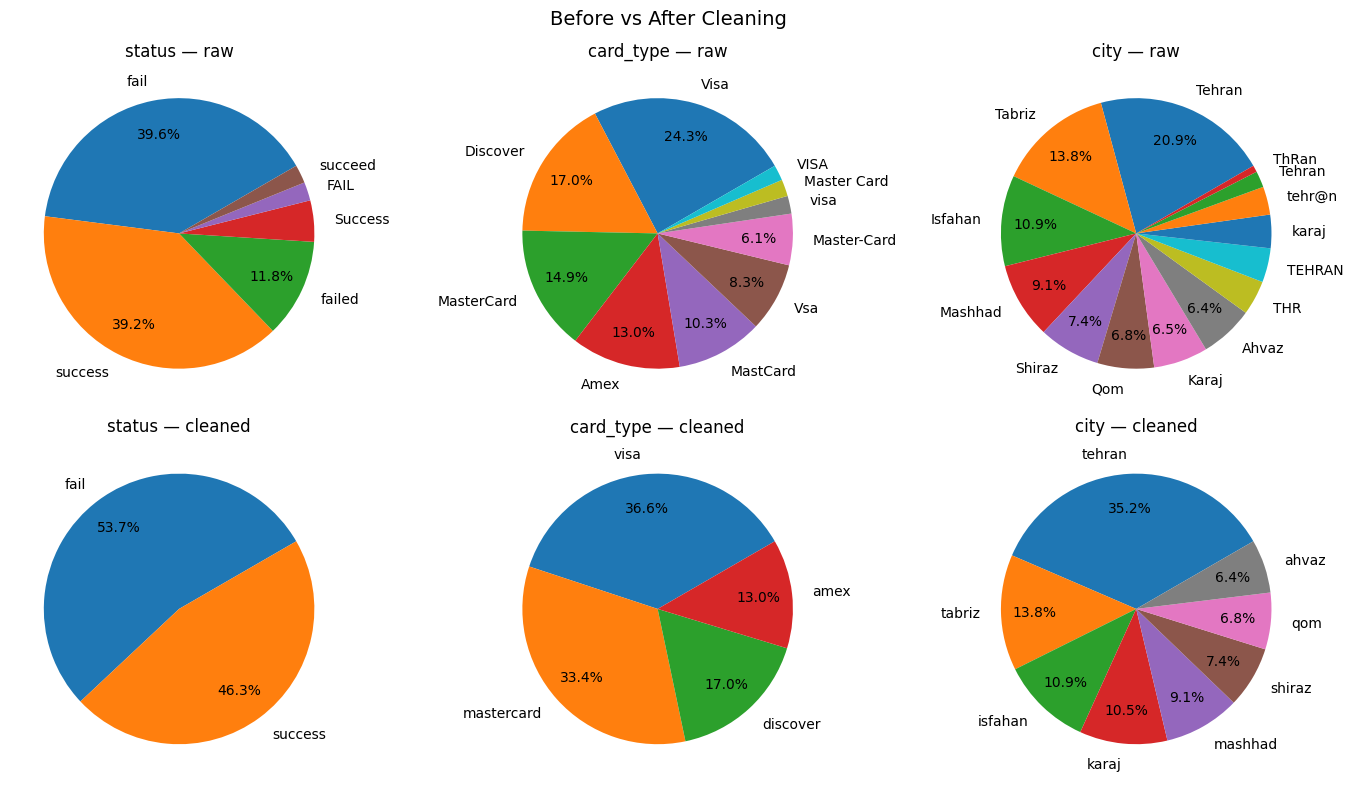


=== WITH OUTLIERS ===
       status                 time card_type    city        amount            id
count   10000                10000      9689    9884  1.000000e+04  10000.000000
unique      2                 1724         4       8           NaN           NaN
top      fail  2025-09-29 11:11:00      visa  tehran           NaN           NaN
freq     5366                   25      3545    3478           NaN           NaN
mean      NaN                  NaN       NaN     NaN  2.954735e+08     50.061200
std       NaN                  NaN       NaN     NaN  1.692035e+09     28.870875
min       NaN                  NaN       NaN     NaN -9.999990e+05      1.000000
25%       NaN                  NaN       NaN     NaN  1.005000e+02     25.000000
50%       NaN                  NaN       NaN     NaN  3.436790e+05     50.000000
75%       NaN                  NaN       NaN     NaN  9.144650e+05     74.000000
max       NaN                  NaN       NaN     NaN  1.000000e+10    100.000000

=== 

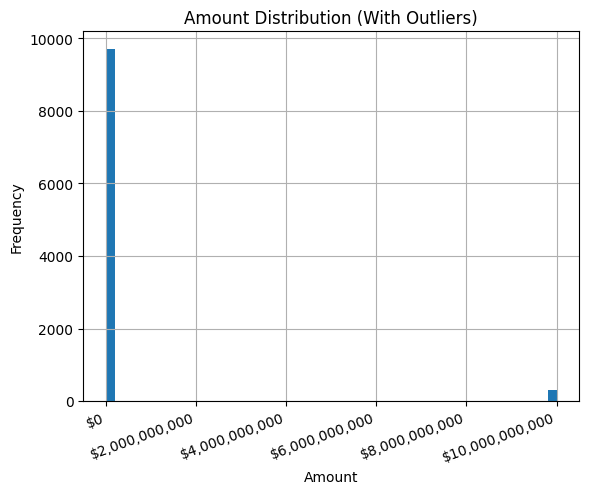

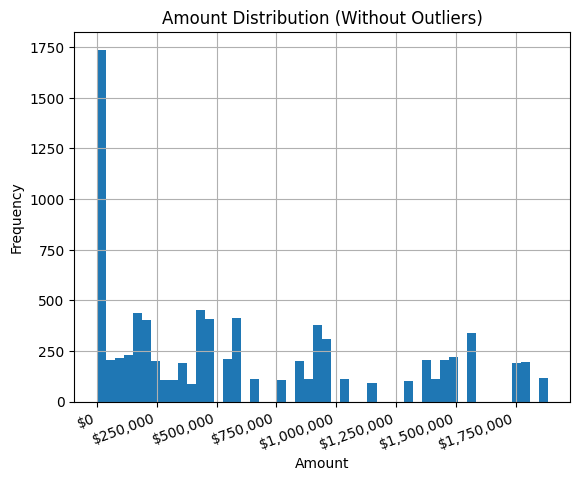

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_raw = pd.read_csv("../data/trx-10k.csv")
df_raw_original = df_raw.copy()

#cleaning up the text entries
text_cols = ["status", "card_type", "city"]
for col in text_cols:
    df_raw[col] = df_raw[col].str.lower().str.strip().str.replace(r"[^a-z0-9 ]", "", regex=True)

#Checking what to set the cutoff at.
for col in text_cols:
    print(f"\n-- {col} --")
    print(df_raw[col].value_counts())

#Mapping similar data to correction
df_raw["status"] = df_raw["status"].replace({
    "failed": "fail",
    "succeed": "success"
})

df_raw["card_type"] = df_raw["card_type"].replace({
    "vsa": "visa",
    "master card": "mastercard",
    "mastcard": "mastercard"
})

df_raw["city"] = df_raw["city"].replace({
    "thran": "tehran",
    "tehrn": "tehran",
    "thr": "tehran"
})

#Checking what to set the cutoff at (after mapping)
for col in text_cols:
    print(f"\n-- {col} --")
    print(df_raw[col].value_counts())

#Setting cutoffs (Worth pointing out this approach but not ideal when we can hard code in the spelling fixes)
cutoffs = {
    "status":    100,
    "card_type": 100,
    "city":      100,
}

#Pie charts (before and after)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Before vs After Cleaning", fontsize=14)

cols = ["status", "card_type", "city"]

for i, col in enumerate(cols):
    before_counts = df_raw_original[col].value_counts()
    axes[0, i].pie(before_counts, labels=before_counts.index, autopct=lambda p: f"{p:.1f}%" if p > 5 else "", pctdistance=0.75, labeldistance=1.15, startangle=30)
    axes[0, i].set_title(f"{col} — raw")

    after_counts = df_raw[col].value_counts()
    axes[1, i].pie(after_counts, labels=after_counts.index, autopct=lambda p: f"{p:.1f}%" if p > 5 else "", pctdistance=0.75, labeldistance=1.15, startangle=30)
    axes[1, i].set_title(f"{col} — cleaned")

plt.tight_layout()
plt.savefig('../figures/Cleaning/pieCharts')
plt.show()

#allow no wrap for describe
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print("\n=== WITH OUTLIERS ===")
print(df_raw.describe(include='all'))

df_no_outliers = df_raw[(df_raw["amount"] < 1e9) & (df_raw["amount"] >= 0)]

print("\n=== WITHOUT OUTLIERS ===")
print(df_no_outliers.describe(include='all'))

plt.figure()
ax = df_raw["amount"].hist(bins=50)
plt.title("Amount Distribution (With Outliers)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=15, ha='right')

plt.savefig('../figures/Cleaning/withOutliers')
plt.show()

plt.figure()
ax = df_no_outliers["amount"].hist(bins=50)
plt.title("Amount Distribution (Without Outliers)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xticks(rotation=15, ha='right')

plt.savefig('../figures/Cleaning/withoutOutliers')
plt.show()


In [6]:

#Cleaning up TEXT data based on cutoffs
for col, cutoff in cutoffs.items():
    counts = df_raw[col].value_counts()
    valid = counts[counts >= cutoff].index
    df_raw[col] = df_raw[col].where(df_raw[col].isin(valid))

df_clean = df_raw.dropna().reset_index(drop=True)
df_clean = df_clean[df_clean["amount"] > 0].reset_index(drop=True)

#Cleaning up date data by converting to a datetime (then to an hour)
df_clean["time"] = pd.to_datetime(df_clean["time"], errors="coerce")
df_clean["time"] = df_clean["time"].dt.hour
mean_time = df_clean["time"].mean()
df_clean = df_clean.fillna(mean_time)

#Printing cleaned TEXT data (time and date still need to be cleaned)
for col in df_clean:
    print(f"\n-- {col} --")
    print(df_clean[col])



-- status --
0       success
1       success
2          fail
3       success
4          fail
         ...   
7471    success
7472       fail
7473    success
7474    success
7475    success
Name: status, Length: 7476, dtype: str

-- time --
0       10
1       13
2        3
3       11
4       21
        ..
7471    14
7472    10
7473    21
7474    10
7475     7
Name: time, Length: 7476, dtype: int32

-- card_type --
0             visa
1       mastercard
2             visa
3             visa
4         discover
           ...    
7471    mastercard
7472          visa
7473      discover
7474    mastercard
7475      discover
Name: card_type, Length: 7476, dtype: str

-- city --
0       tehran
1       tehran
2       tehran
3       tehran
4       tehran
         ...  
7471     karaj
7472    tehran
7473    tabriz
7474    tehran
7475    tehran
Name: city, Length: 7476, dtype: str

-- amount --
0       1427657.0
1       1578078.0
2        250000.0
3       1782689.0
4       1050805.0
          ...

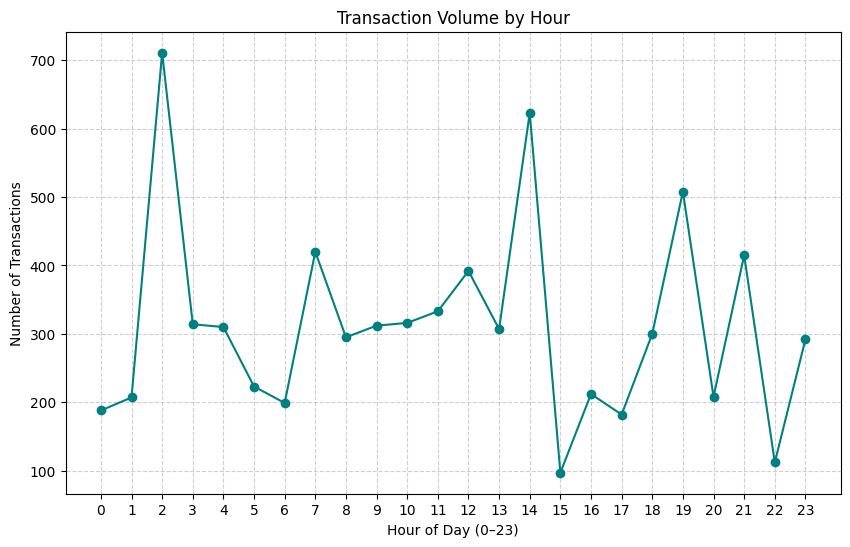

In [ ]:
qty_by_hour = df_clean.groupby("time").size().reset_index(name="transaction_count")

plt.figure(figsize=(10, 6))
plt.plot(qty_by_hour["time"], qty_by_hour["transaction_count"], marker="o", color="teal")

plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Transactions")
plt.title("Transaction Volume by Hour")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('../figures/Cleaning/transactionQuantityByHour')
plt.show()

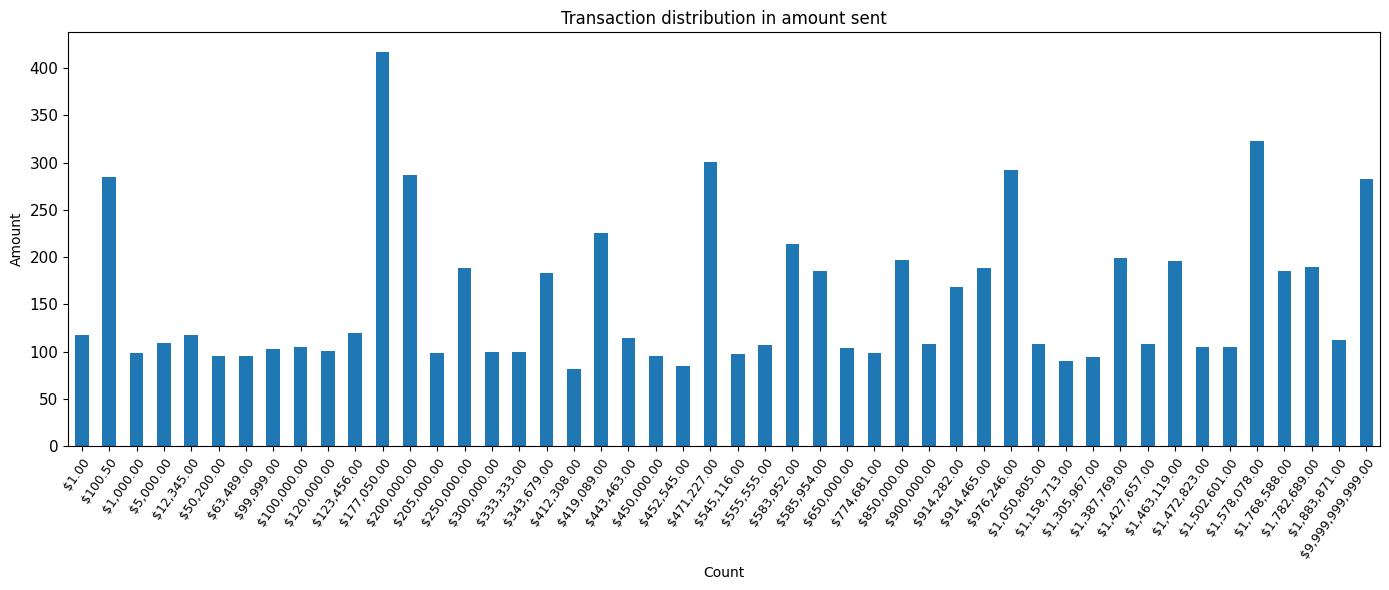

In [7]:
df_clean['amount'] = df_clean['amount'].round(2)
df_by_amount_group = df_clean.groupby('amount').size()

#Showing the distribution of transaction amounts
amountFig = df_by_amount_group.plot(kind='bar', figsize=(14, 6))
amountFig.set_xlabel('Count')
amountFig.set_ylabel('Amount')
amountFig.set_title('Transaction distribution in amount sent')
amountFig.tick_params(axis='x', labelsize=11, rotation=90)
amountFig.tick_params(axis='y', labelsize=11)

labels = [f'${x:,.2f}' for x in df_by_amount_group.index]
amountFig.set_xticklabels(labels, fontsize=9, rotation=55, ha='right', rotation_mode='anchor')

plt.tight_layout()
plt.savefig('../figures/Cleaning/transactionDistributionByDollar')
plt.show()

Q1: 200000.00
Median: 555555.00
Q3: 1305967.00
IQR: 1105967.00


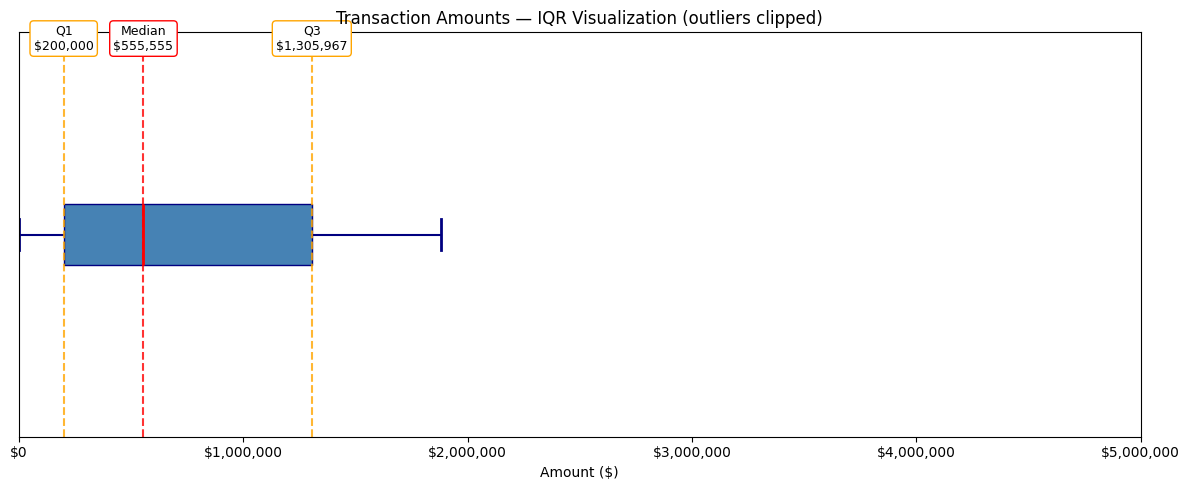

In [8]:
#IQR Data analysis
Q1 = df_clean['amount'].quantile(0.25)
Q2 = df_clean['amount'].quantile(0.50)
Q3 = df_clean['amount'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:.2f}")
print(f"Median: {Q2:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

#IQR Visualization
fig2, ax2 = plt.subplots(figsize=(12, 5))

#prettifying plot
ax2.boxplot( df_clean['amount'], vert=False, patch_artist=True, boxprops=dict(facecolor='steelblue', color='navy'), medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy', linewidth=1.5), capprops=dict(color='navy', linewidth=2), flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))

#restrict chart view (outlier protection)
x_min = max(0, Q1 - 1.5 * IQR)
x_max = Q3 + 3 * IQR
ax2.set_xlim(x_min, x_max)

label_heights = [1.45, 1.45, 1.45]
colors = ['orange', 'red', 'orange']

for val, label, height, color in zip([Q1, Q2, Q3], ['Q1', 'Median', 'Q3'], label_heights, colors):
    ax2.axvline(x=val, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    ax2.text(val, height, f'{label}\n${val:,.0f}', ha='center', va='bottom', fontsize=9, bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3'))

ax2.set_xticks(ax2.get_xticks())
ax2.set_xticklabels([f'${x:,.0f}' for x in ax2.get_xticks()])
ax2.set_title('Transaction Amounts — IQR Visualization (outliers clipped)')
ax2.set_xlabel('Amount ($)')
ax2.set_yticks([])

plt.tight_layout()
plt.show()